# CME Futures — Exploratory Data Analysis

**Docker image**: `ml4t`

**Purpose**: Profile the 30-product CME futures dataset (Databento, hourly,
2011–2025) and surface the contract / continuous structure that downstream
notebooks rely on.

**Learning objectives**:

- Understand the futures data hierarchy: product → contract → continuous series.
- Load individual contracts and continuous (rolled) series via
  `load_cme_futures` and inspect the canonical `timestamp` / `product`
  schema.
- Summarize per-product coverage and group products by asset class.
- Verify OHLC invariants on a representative continuous series.

**Book reference**: §2.2, "The asset-class market data landscape" - the futures part of it.

**Prerequisites**: `data` package on `PYTHONPATH`; CME parquet present at
`ML4T_DATA_PATH/futures/`. Run `python data/futures/market/download.py` if
missing (Databento API key required).

In [1]:
"""CME Futures — Exploratory data analysis of the futures universe."""

import plotly.graph_objects as go
import polars as pl

from data import list_cme_products, load_cme_futures
from utils.data_quality import check_ohlc_invariants
from utils.style import COLORS, show_plotly_with_alt

In [2]:
# Production defaults — Papermill injects overrides for CI
MAX_SYMBOLS = 0  # 0 = all

## 1. Configuration and Data Discovery

The futures data uses a Hive-partitioned structure for efficient queries:
- `futures/continuous/product={PRODUCT}/`: Volume-rolled continuous contracts (hourly)
- `futures/individual/{PRODUCT}/data.parquet`: Individual contract price data

We use `load_cme_futures()` for proper data loading with partition pruning.

In [3]:
# Discover available products via the CME loader
products = list_cme_products()

print("=== Futures Universe ===")
print(f"Available products: {len(products)}")
print(f"\nProducts: {', '.join(products)}")

=== Futures Universe ===
Available products: 30

Products: 6A, 6B, 6C, 6E, 6J, 6S, CL, ES, GC, GF, HE, HG, HO, LE, NG, NQ, PL, RB, RTY, SI, YM, ZB, ZC, ZF, ZL, ZM, ZN, ZS, ZT, ZW


Map each product to a coarse asset-class bucket. The mapping covers every
product in the dataset; downstream chapters use the same bucket labels for
universe-construction and risk reporting.

In [4]:
ASSET_CLASS_MAP = {
    "ES": "Equity Index",
    "NQ": "Equity Index",
    "YM": "Equity Index",
    "RTY": "Equity Index",
    "ZN": "Rates",
    "ZB": "Rates",
    "ZF": "Rates",
    "ZT": "Rates",
    "CL": "Energy",
    "NG": "Energy",
    "HO": "Energy",
    "RB": "Energy",
    "GC": "Metals",
    "SI": "Metals",
    "HG": "Metals",
    "PL": "Metals",
    "6E": "FX",
    "6J": "FX",
    "6B": "FX",
    "6A": "FX",
    "6C": "FX",
    "6S": "FX",
    "ZC": "Grains",
    "ZS": "Grains",
    "ZW": "Grains",
    "ZM": "Grains",
    "ZL": "Grains",
    "LE": "Livestock",
    "HE": "Livestock",
    "GF": "Livestock",
}

# One on-brand color per asset-class bucket, reused by every chart below so a
# bucket keeps the same color across the notebook.
ASSET_CLASS_COLORS = {
    "Equity Index": COLORS["blue"],
    "Rates": COLORS["amber"],
    "Energy": COLORS["copper"],
    "Metals": COLORS["slate"],
    "FX": COLORS["neutral"],
    "Grains": COLORS["positive"],
    "Livestock": COLORS["blue_light"],
}

In [5]:
unmapped = [p for p in products if p not in ASSET_CLASS_MAP]
if unmapped:
    raise ValueError(
        f"{unmapped} have no asset class. The map above is written by hand and the product "
        "list comes from the data, so a newly captured product has to be added here."
    )

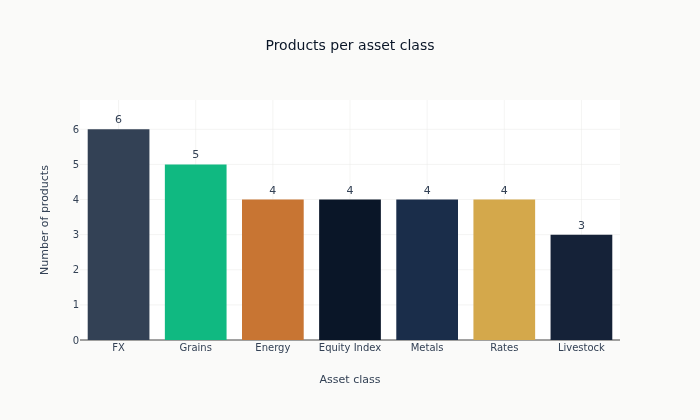

In [6]:
class_counts = (
    pl.DataFrame({"product": products})
    .with_columns(asset_class=pl.col("product").replace(ASSET_CLASS_MAP))
    .group_by("asset_class")
    .len()
    .sort(["len", "asset_class"], descending=[True, False])
)

fig = go.Figure(
    go.Bar(
        x=class_counts["asset_class"].to_list(),
        y=class_counts["len"].to_list(),
        marker_color=[ASSET_CLASS_COLORS[c] for c in class_counts["asset_class"].to_list()],
        text=class_counts["len"].to_list(),
        textposition="outside",
    )
)
fig.update_layout(
    title="Products per asset class",
    xaxis_title="Asset class",
    yaxis_title="Number of products",
    height=420,
    showlegend=False,
)
show_plotly_with_alt(
    fig,
    "A bar chart counting products in each asset-class bucket, sorted from largest to "
    "smallest, with the count written above each bar. No bucket holds more than about a "
    "fifth of the universe.",
)

The universe is spread across asset classes rather than concentrated in one, which is what
makes it usable for cross-asset work later. It is not balanced, though, so the counts above
are worth carrying forward rather than assuming an even split.

## 2. Data Structure Example: E-mini S&P 500 (ES)

### Futures Key Hierarchy

| Level | Example | Description |
|-------|---------|-------------|
| **Product** | ES | The underlying (E-mini S&P 500) |
| **Contract** | ESH4 | Specific expiration (March 2024) |
| **Continuous** | c0, c1 | Front month, first deferred |

In [7]:
es_individual = load_cme_futures(products=["ES"], continuous=False, frequency="hourly")

print("=== ES Individual Contracts ===")
print(f"Shape: {es_individual.shape}")
print(f"Columns: {es_individual.columns}")
print(f"Date range: {es_individual['timestamp'].min()} to {es_individual['timestamp'].max()}")
print(f"Unique contracts: {es_individual['instrument_id'].n_unique()}")

=== ES Individual Contracts ===
Shape: (19361, 10)
Columns: ['timestamp', 'rtype', 'publisher_id', 'instrument_id', 'open', 'high', 'low', 'close', 'volume', 'product']
Date range: 2016-01-03 00:00:00+00:00 to 2025-12-30 00:00:00+00:00
Unique contracts: 194


In [8]:
es_continuous = load_cme_futures(products=["ES"], tenors=[0], continuous=True, frequency="hourly")

print("=== ES Continuous Series (front month) ===")
print(f"Shape: {es_continuous.shape}")
print(f"Date range: {es_continuous['timestamp'].min()} to {es_continuous['timestamp'].max()}")

=== ES Continuous Series (front month) ===
Shape: (89031, 13)
Date range: 2011-01-02 23:00:00+00:00 to 2025-12-30 23:00:00+00:00


The front-month continuous series splices successive contracts into one price history.
Plotted at daily resolution it runs unbroken, which is what a roll is supposed to look
like from the outside; `06_futures_continuous` opens up what the splice does to the
returns either side of it.

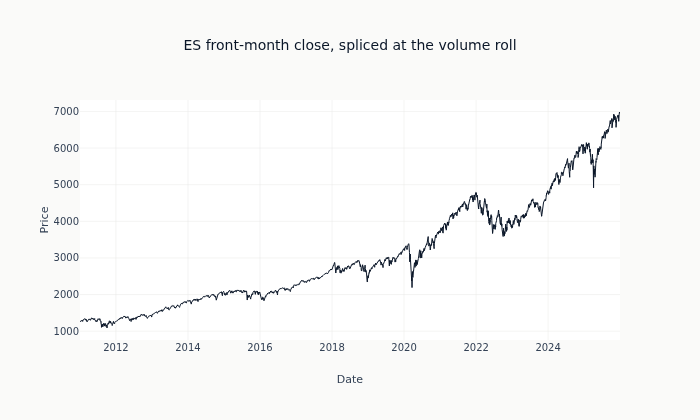

In [9]:
es_daily = (
    es_continuous.sort("timestamp")
    .group_by(pl.col("timestamp").dt.date().alias("date"), maintain_order=True)
    .agg(pl.col("close").last())
)

fig = go.Figure(
    go.Scatter(
        x=es_daily["date"].to_list(),
        y=es_daily["close"].to_list(),
        mode="lines",
        line=dict(color=COLORS["blue"], width=1),
        name="ES front month",
    )
)
fig.update_layout(
    title="ES front-month close, spliced at the volume roll",
    xaxis_title="Date",
    yaxis_title="Price",
    height=420,
)
show_plotly_with_alt(
    fig,
    "A daily closing price line for the E-mini S&P 500 front-month continuous series. It "
    "runs unbroken across the whole window, rising overall with the drawdowns of 2020 and "
    "2022 visible, and shows no step or gap where one contract hands over to the next.",
)

No break is visible at the splices, which is the point and also the risk: the series looks
continuous whether or not the roll was handled correctly, so nothing about this chart
establishes that it was. `06_futures_continuous` builds the same series from individual
contracts and checks it against the vendor's, which is the test this picture cannot perform.

Each individual contract trades for a finite window before expiry. Aggregating
by `instrument_id` shows the rollover pattern — quarterly contracts overlap
during the roll period.

In [10]:
contract_stats = (
    es_individual.group_by("instrument_id")
    .agg(
        pl.col("timestamp").min().alias("first_trade"),
        pl.col("timestamp").max().alias("last_trade"),
        pl.col("volume").sum().alias("total_volume"),
        pl.len().alias("observations"),
    )
    .sort("first_trade")
)
print(f"Total ES contracts: {len(contract_stats)}")

Total ES contracts: 194


Each of the most recent contracts is drawn as a horizontal bar spanning its trading window.
Where neighbouring bars overlap, both the expiring contract and the next one are quoted at
the same time; that overlap is the roll period, and it is what a continuous series has to
choose a date inside.

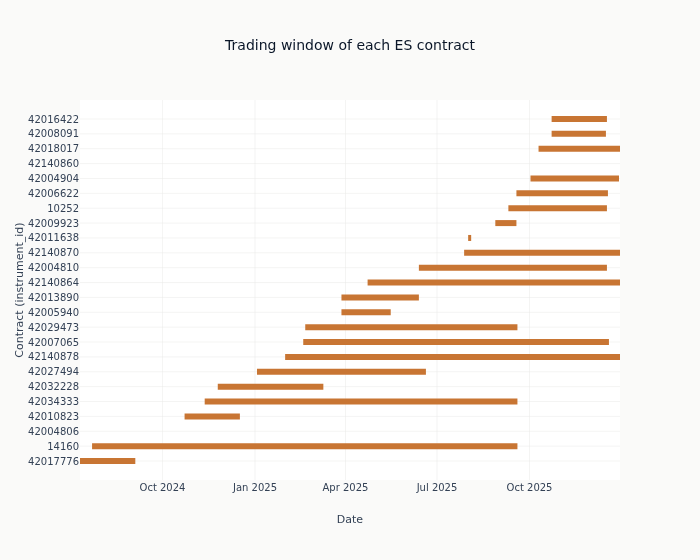

In [11]:
RECENT_CONTRACTS = 24
recent = contract_stats.tail(RECENT_CONTRACTS)

fig = go.Figure()
for row in recent.iter_rows(named=True):
    fig.add_trace(
        go.Scatter(
            x=[row["first_trade"], row["last_trade"]],
            y=[str(row["instrument_id"]), str(row["instrument_id"])],
            mode="lines",
            line=dict(color=COLORS["copper"], width=6),
            showlegend=False,
        )
    )
fig.update_layout(
    title="Trading window of each ES contract",
    xaxis_title="Date",
    yaxis_title="Contract (instrument_id)",
    yaxis=dict(type="category"),
    height=560,
)
show_plotly_with_alt(
    fig,
    "One horizontal bar per contract, stacked in order of first trade. Each bar spans "
    "several months and starts before the bar below it ends, so consecutive contracts are "
    "quoted at the same time for part of their lives.",
)

Each contract trades for months, and neighbouring contracts overlap for a stretch around the
roll. That overlap is what makes a volume-based roll possible at all: for those weeks both
contracts are liquid, and the question of which one is the front month has an answer that
changes day to day.

## 3. Coverage Summary

Check data availability across all products.

Summarize per-product coverage by loading the front-month continuous series
(`tenor=0`) for every product and recording its row count and date range.

In [12]:
def get_product_coverage(product_list: list[str]) -> pl.DataFrame:
    """Summarize continuous series coverage for each product (front month)."""
    summaries = []
    for product in product_list:
        df = load_cme_futures(products=[product], tenors=[0], continuous=True, frequency="hourly")
        summaries.append(
            {
                "product": product,
                "asset_class": ASSET_CLASS_MAP[product],
                "rows": len(df),
                "start_date": str(df["timestamp"].min())[:10],
                "end_date": str(df["timestamp"].max())[:10],
            }
        )
    return pl.DataFrame(summaries)

In [13]:
coverage = get_product_coverage(products)
print(f"Loaded {len(coverage)} continuous series, {coverage['rows'].sum():,} hourly bars total")
print(
    f"Earliest history starts {coverage['start_date'].min()}; latest starts {coverage['start_date'].max()}"
)

Loaded 30 continuous series, 2,376,057 hourly bars total
Earliest history starts 2011-01-02; latest starts 2017-07-09


One horizontal bar per product spans its continuous front-month history, grouped and
coloured by asset class. A bar that starts late is a product Databento began capturing
later, not a contract that began trading then - the distinction matters because a
backtest reading this panel sees the second and gets the first.

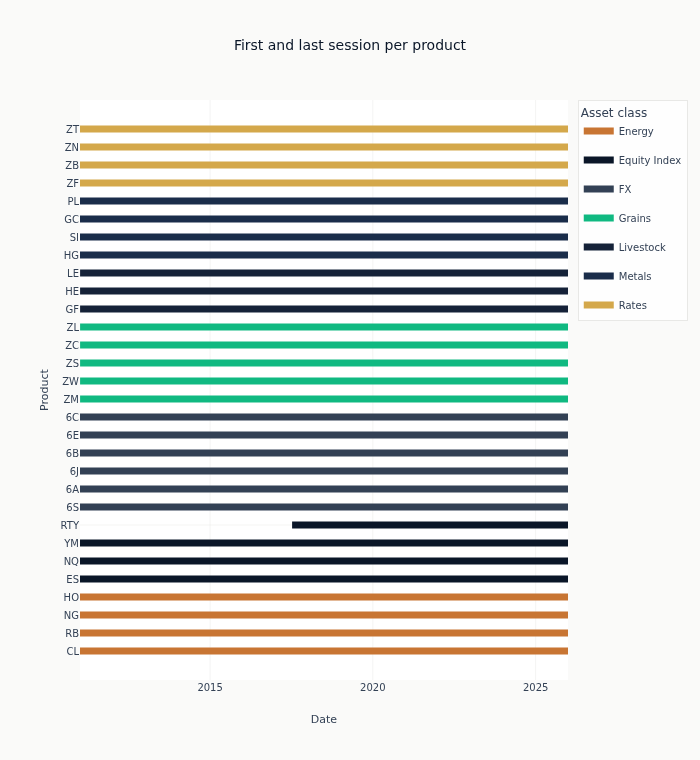

In [14]:
cov_timeline = coverage.with_columns(
    pl.col("start_date").str.to_date(),
    pl.col("end_date").str.to_date(),
).sort(["asset_class", "start_date"])

fig = go.Figure()
seen: set[str] = set()
for row in cov_timeline.iter_rows(named=True):
    cls = row["asset_class"]
    fig.add_trace(
        go.Scatter(
            x=[row["start_date"], row["end_date"]],
            y=[row["product"], row["product"]],
            mode="lines",
            line=dict(color=ASSET_CLASS_COLORS[cls], width=7),
            name=cls,
            legendgroup=cls,
            showlegend=cls not in seen,
        )
    )
    seen.add(cls)
fig.update_layout(
    title="First and last session per product",
    xaxis_title="Date",
    yaxis_title="Product",
    height=760,
    legend_title="Asset class",
)
show_plotly_with_alt(
    fig,
    "One horizontal bar per product spanning its continuous history, grouped and coloured "
    "by asset class. Most bars start at the left edge and run to the right edge; a small "
    "number begin several years in, and none stops early.",
)

Most products cover the whole window and a few enter part-way through, so a panel built by
requiring every product on every date would be shorter than the data allows. The start dates
above are the ones to check against before choosing a common sample.

## 4. Data Quality

In [15]:
invariants = check_ohlc_invariants(es_continuous)
print("=== OHLC Invariants (ES Continuous) ===")
for row in invariants.iter_rows(named=True):
    status = "[OK]" if row["valid_pct"] >= 99.99 else "[WARN]"
    print(f"  {status} {row['check']}: {row['valid_pct']:.2f}%")

=== OHLC Invariants (ES Continuous) ===
  [OK] high_gte_low: 100.00%
  [OK] high_gte_open: 100.00%
  [OK] high_gte_close: 100.00%
  [OK] low_lte_open: 100.00%
  [OK] low_lte_close: 100.00%
  [OK] volume_non_negative: 100.00%


## Key takeaways

- **A futures product is not a series.** Product, contract and continuous series are three
  different things. Each contract has its own observed price history and stops at expiry;
  the continuous series is built by joining successive contracts into one long history that
  no single instrument ever traded. Everything downstream reads the continuous front month,
  and anything that needs to know which contract a price came from goes back to
  `instrument_id`.
- **Continuous series are constructed, and the construction is a choice.** The unbroken
  line here is the result of splicing at a volume roll. A different roll rule produces a
  different history from the same contracts, which is why the adjustment method is a
  decision the next notebook makes explicitly rather than a property of the data.
- **Contract windows overlap, and the overlap is where the roll lives.** Two contracts
  quoting at once is not duplication; it is the period a roll rule has to pick a date
  inside, and the width of that window is what makes the choice consequential.
- **A history that starts late is usually a capture date, not a listing date.** The
  difference is invisible in the panel and decisive for a backtest, which is why the
  coverage figure draws every product's history rather than reporting a start date.
- **The classification is hand-written, so check it against the data.** The asset-class map
  is this repository's, not the exchange's, and the notebook now fails with a readable
  message if the loader returns a product the map has never heard of.

**Known limitations.** OHLC invariants are checked on one product's continuous series rather
than across the universe, and no notebook in this chapter checks them across the CME panel -
`13_data_quality_framework` demonstrates the validation methods on US equities, so the
technique transfers and the coverage does not. The continuous
series here are unadjusted, so a return computed across a roll includes the price gap
between two contracts rather than a market move. And hourly bars are stamped in UTC, which
is not the grid any of these products trades on - `05_futures_session_aggregation` is what
puts them on a session.

**Next**: `05_futures_session_aggregation` aligns hourly bars to CME sessions;
`06_futures_continuous` covers roll detection and the ratio, difference and calendar
adjustments. Chapter 8 builds term-structure and roll-yield features on top.